# Model Training and Evaluation
Logistic Regression, Random Forest, KNN, XGBoost  
Class imbalance handled with SMOTE.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from src.evaluation import (
    get_metrics, plot_confusion_matrix, plot_roc,
    plot_precision_recall, find_optimal_threshold, plot_business_cost
)

sns.set_theme(style='whitegrid')

In [2]:
X_train = pd.read_csv('../outputs/X_train.csv')
X_test  = pd.read_csv('../outputs/X_test.csv')
y_train = pd.read_csv('../outputs/y_train.csv').squeeze()
y_test  = pd.read_csv('../outputs/y_test.csv').squeeze()

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (5634, 26) | Test: (1409, 26)


## Class Imbalance Handling — SMOTE

The training set is imbalanced (~26.5% churn). SMOTE (Synthetic Minority Oversampling Technique) generates synthetic minority samples so every model trains on a balanced 50/50 split. Crucially, SMOTE is applied **only to training data** — the test set remains in its original distribution so evaluation metrics reflect real-world conditions.

In [ ]:
print('Before SMOTE:', dict(y_train.value_counts().sort_index()))

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print('After SMOTE: ', dict(pd.Series(y_train).value_counts().sort_index()))
print('New train shape:', X_train.shape)

## Logistic Regression

In [3]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

cv_lr = cross_val_score(lr, X_train, y_train, cv=5, scoring='f1')
print(f'CV F1: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')

lr.fit(X_train, y_train)

CV F1: 0.6410 ± 0.0205


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [4]:
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]
metrics_lr = get_metrics(y_test, y_pred_lr, y_prob_lr)
print(metrics_lr)

{'Accuracy': 0.7437899219304471, 'Precision': 0.51138353765324, 'Recall': 0.7807486631016043, 'F1-Score': 0.617989417989418, 'MCC': 0.4597721845516137, 'ROC-AUC': 0.8488516882378776}


## Random Forest

In [5]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(rf_base, param_grid, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print('Best params:', rf_grid.best_params_)
rf = rf_grid.best_estimator_

Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [6]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
metrics_rf = get_metrics(y_test, y_pred_rf, y_prob_rf)
print(metrics_rf)

{'Accuracy': 0.7743080198722498, 'Precision': 0.5566801619433198, 'Recall': 0.7352941176470589, 'F1-Score': 0.6336405529953917, 'MCC': 0.48463464550629737, 'ROC-AUC': 0.8510307680384406}


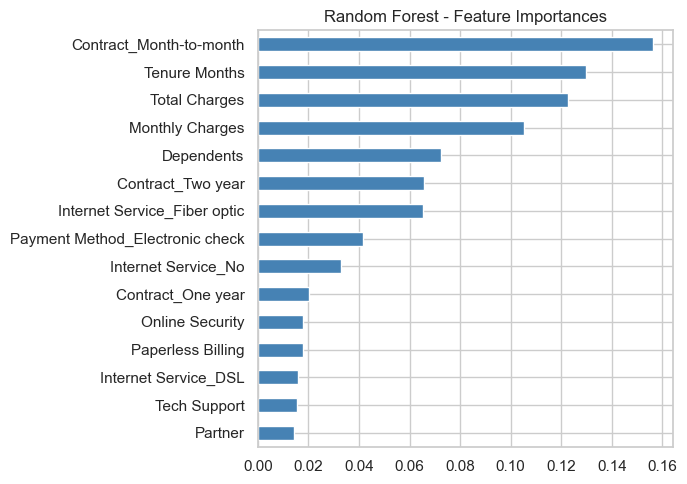

In [7]:
# feature importance
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 5))
top15.sort_values().plot(kind='barh', color='steelblue')
plt.title('Random Forest - Feature Importances')
plt.tight_layout()
plt.savefig('../outputs/figures/08_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## KNN

Best K: 19


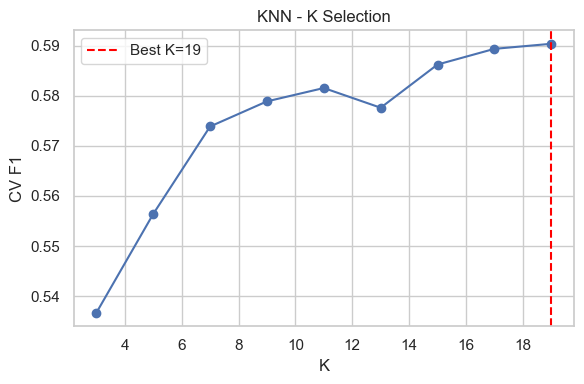

In [8]:
# try different k values to find the best one
k_values = range(3, 21, 2)
f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    score = cross_val_score(knn, X_train, y_train, cv=5, scoring='f1').mean()
    f1_scores.append(score)

best_k = list(k_values)[np.argmax(f1_scores)]
print('Best K:', best_k)

plt.figure(figsize=(6, 4))
plt.plot(list(k_values), f1_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K')
plt.ylabel('CV F1')
plt.title('KNN - K Selection')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/09_knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]
metrics_knn = get_metrics(y_test, y_pred_knn, y_prob_knn)
print(metrics_knn)

{'Accuracy': 0.7792760823278921, 'Precision': 0.5863013698630137, 'Recall': 0.5721925133689839, 'F1-Score': 0.5791610284167794, 'MCC': 0.42965849019637165, 'ROC-AUC': 0.8166227492314448}


## XGBoost

In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

cv_xgb = cross_val_score(xgb, X_train, y_train, cv=5, scoring='f1')
print(f'CV F1: {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}')

xgb.fit(X_train, y_train)

In [ ]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
metrics_xgb = get_metrics(y_test, y_pred_xgb, y_prob_xgb)
print(metrics_xgb)

In [ ]:
importances_xgb = pd.Series(xgb.feature_importances_, index=X_train.columns)
top15_xgb = importances_xgb.sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 5))
top15_xgb.sort_values().plot(kind='barh', color='darkorange')
plt.title('XGBoost - Feature Importances')
plt.tight_layout()
plt.savefig('../outputs/figures/09_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrices

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

plot_confusion_matrix(y_test, y_pred_lr,  'Logistic Regression', axes[0, 0])
plot_confusion_matrix(y_test, y_pred_rf,  'Random Forest',       axes[0, 1])
plot_confusion_matrix(y_test, y_pred_knn, 'KNN',                 axes[1, 0])
plot_confusion_matrix(y_test, y_pred_xgb, 'XGBoost',             axes[1, 1])

plt.tight_layout()
plt.savefig('../outputs/figures/10_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## ROC Curves

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'KNN': knn,
    'XGBoost': xgb,
}
plot_roc(models, X_test, y_test, ax)

plt.tight_layout()
plt.savefig('../outputs/figures/11_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Precision-Recall Curves

For imbalanced datasets the PR curve is more informative than ROC: it focuses on the minority (churn) class and is not inflated by the large number of true negatives. **Average Precision (AP)** summarises the curve as a single number equivalent to the area under it.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_precision_recall(models, X_test, y_test, ax)
plt.tight_layout()
plt.savefig('../outputs/figures/12_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Threshold Optimisation

The default decision threshold (0.5) is rarely optimal for imbalanced problems. We sweep thresholds from 0.05 to 0.95 and pick the one that maximises **F1** on the test set for each model.

In [ ]:
thr_results = {}
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    t, f1 = find_optimal_threshold(y_test, y_prob)
    thr_results[name] = {'Optimal Threshold': round(t, 3), 'Best F1': round(f1, 4)}

print(pd.DataFrame(thr_results).T.to_string())

## Business Cost Analysis

Churn prediction has an asymmetric cost structure:

| Error type | Business meaning | Assumed cost |
|---|---|---|
| **False Negative** | Churner missed — customer is lost | **\$500** |
| **False Positive** | Loyal customer contacted unnecessarily | **\$50** |

We plot total cost as a function of the decision threshold to find the **minimum-cost operating point** for the best model (Random Forest).

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, model) in zip(axes, [('Random Forest', rf), ('XGBoost', xgb)]):
    y_prob = model.predict_proba(X_test)[:, 1]
    opt_t, opt_cost = plot_business_cost(y_test, y_prob, name, ax)
    print(f'{name}: optimal threshold={opt_t:.2f}, total cost=${opt_cost:,.0f}')

plt.tight_layout()
plt.savefig('../outputs/figures/13_business_cost.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Comparison

In [12]:
results = {
    'Logistic Regression': metrics_lr,
    'Random Forest':       metrics_rf,
    'KNN':                 metrics_knn,
    'XGBoost':             metrics_xgb,
}

comparison = pd.DataFrame(results).T.round(4)
display(comparison)

In [13]:
comparison.plot(kind='bar', figsize=(12, 5), rot=0, colormap='Set2')
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figures/14_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Models

In [14]:
import os
os.makedirs('../outputs/models', exist_ok=True)

joblib.dump(lr,  '../outputs/models/logistic_regression.pkl')
joblib.dump(rf,  '../outputs/models/random_forest.pkl')
joblib.dump(knn, '../outputs/models/knn.pkl')
joblib.dump(xgb, '../outputs/models/xgboost.pkl')

print('Models saved.')